In [153]:
import asyncio
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import time
import copy
import glob
import os
import warnings
warnings.simplefilter("ignore")

In [ ]:
def read_pq(date: str):
    root = f"C:/GIT/market_game/market_data/NIFTY_FUT/2026-02-{date}"

    all_files = glob.glob(
        "**/*.parquet",
        root_dir=root,
        recursive=True
    )

    df_bid = pd.DataFrame()
    df_ask = pd.DataFrame()

    i = 1
    
    for file_name in all_files:
        try:
            df = pd.read_parquet(os.path.join(root, file_name))
        except:
            continue
        
        _bid1 = df[df["side"] == "Bid"].reset_index(drop=True)
        _ask1 = df[df["side"] == "Ask"].reset_index(drop=True)
        
        
        for ser in range(0,max(_bid1.shape[0], _ask1.shape[0]), 20):
            _bid2 = _bid1.iloc[ser:ser+20].sort_values('price')
            _ask2 = _ask1.iloc[ser:ser+20].sort_values('price', ascending=False)
            _bid2['time_idx'] = i
            _ask2['time_idx'] = i
            
            i += 1
            df_bid = pd.concat([df_bid, _bid2], axis= 0)
            df_ask = pd.concat([df_ask, _ask2], axis= 0)

    return df_bid, df_ask

df_bid, df_ask = read_pq('19_')
# df_bid.to_excel('temp_bid.xlsx')
# df_ask.to_excel('tempAsk.xlsx')


KeyboardInterrupt: 

In [150]:
def read_pq2(date: str):
    root = f"C:/GIT/market_game/market_data/NIFTY_FUT/2026-02-{date}"

    all_files = glob.glob("**/*.parquet", root_dir=root, recursive=True)

    bid_frames = []
    ask_frames = []

    for file_name in all_files:
        try:
            df = pd.read_parquet(os.path.join(root, file_name))
        except Exception:
            continue

        df = df.sort_values("ts")

        # Assign packet of size 20 per ts and side
        df["packet"] = (
            df.groupby(["side", "ts"])
              .cumcount()
              .floordiv(20)
        )

        bid_frames.append(df[df["side"] == "Bid"])
        ask_frames.append(df[df["side"] == "Ask"])

    if not bid_frames:
        return pd.DataFrame(), pd.DataFrame()

    df_bid = pd.concat(bid_frames, ignore_index=True)
    df_ask = pd.concat(ask_frames, ignore_index=True)

    # Create global monotonically increasing time index
    df_bid["time_idx"] = (
        df_bid.groupby(["ts", "packet"])
              .ngroup()
              .add(1)
    )

    df_ask["time_idx"] = (
        df_ask.groupby(["ts", "packet"])
              .ngroup()
              .add(1)
    )

    return df_bid, df_ask

In [151]:
df_bid2, df_ask2 = read_pq2('19_')

In [152]:
df_bid2.to_excel('tryBid2.xlsx')

In [82]:
time_point = (pd.concat([df_bid['ts'], df_ask['ts']])).drop_duplicates().sort_values(ignore_index=True)

_point = []
for time in time_point:
    try: _bid = df_bid[df_bid['ts'] == time]['price'].max().item()
    except: _bid = df_bid[df_bid['ts'] == time]['price'].max()
    try: _ask = df_ask[df_ask['ts'] == time]['price'].min().item()
    except: 
        #nan is not an item this is to filter nan
        _ask = df_ask[df_ask['ts'] == time]['price'].min()
    _mid = 0.5 * (_bid + _ask)
    _point.append([time, _mid]) 



In [83]:
mid_price = pd.DataFrame(_point, columns=['time','price'])
_mid_price = mid_price.copy()
_mid_price['time'] = pd.to_datetime(_mid_price['time'],unit = 'ns').dt.time
_mid_price = _mid_price.set_index('time')

<Axes: xlabel='time'>

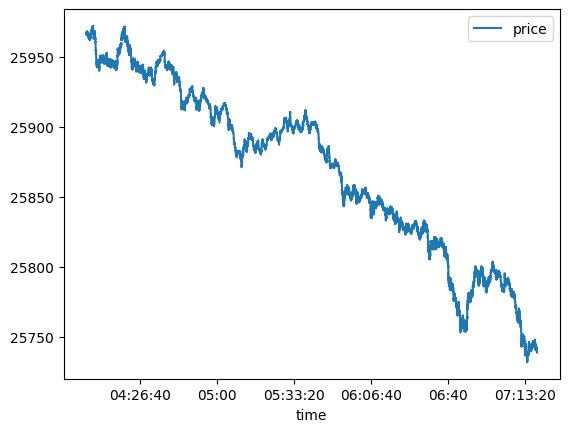

In [84]:
_mid_price.plot()

In [85]:
mid_price

,time,price
0,1771473804484112900,25966.25
1,1771473804980690200,25967.10
2,1771473805477250800,25966.75
3,1771473805973416300,25967.20
4,1771473806486519900,25967.40
...,...,...
24396,1771485501354681700,25740.10
24397,1771485501854769100,25740.10
24398,1771485502355269900,25741.10
24399,1771485502853846700,25741.10


In [87]:
_mid_price.head(10)

,price
time,
04:03:24.484112,25966.25
04:03:24.980690,25967.10
04:03:25.477250,25966.75
04:03:25.973416,25967.20
04:03:26.486519,25967.40
04:03:26.981640,25967.50
04:03:27.478234,25967.15
04:03:27.975854,25967.45
04:03:28.487253,25967.05


In [94]:
pd.concat([df_bid[df_bid['ts']==df_bid['ts'][0]], df_ask[df_ask['ts']==df_bid['ts'][0]]], axis= 1)

,ts,security_id,side,price,qty,ts,security_id,side,price,qty
0,1771473804484112900,51714,Bid,25965.0,650,1771473804484112900,51714,Ask,25967.5,65
1,1771473804484112900,51714,Bid,25964.9,65,1771473804484112900,51714,Ask,25967.6,65
2,1771473804484112900,51714,Bid,25963.0,65,1771473804484112900,51714,Ask,25967.7,65
3,1771473804484112900,51714,Bid,25962.7,65,1771473804484112900,51714,Ask,25968.5,65
4,1771473804484112900,51714,Bid,25962.0,130,1771473804484112900,51714,Ask,25968.6,195
5,1771473804484112900,51714,Bid,25961.8,7605,1771473804484112900,51714,Ask,25968.8,130
6,1771473804484112900,51714,Bid,25961.4,65,1771473804484112900,51714,Ask,25968.9,65
7,1771473804484112900,51714,Bid,25961.2,65,1771473804484112900,51714,Ask,25969.0,390
8,1771473804484112900,51714,Bid,25961.0,260,1771473804484112900,51714,Ask,25969.1,325
9,1771473804484112900,51714,Bid,25960.6,65,1771473804484112900,51714,Ask,25969.2,585
